# PPO Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement PPO or a simplified variant
- Train and stabilize policy optimization

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 3, lesson 02 "Loss Functions and Regularization" — PPO's clipped surrogate is a regularized objective: the clip is a penalty that stops one update from moving the policy too far, the same "keep the solution well-behaved" idea you applied to model weights.

**Used later in:** Course 10 (AIAT 124) — Unit 5, lesson 02 "Future Trends and Research", which lists alignment via RLHF as the change that separated ChatGPT from raw GPT-3; PPO is the algorithm most commonly used inside that loop.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces **Proximal Policy Optimization (PPO)**, one of the most widely used deep RL algorithms.

Students should focus on the intuition: PPO improves a policy, but tries not to change it too aggressively in one update.

Why this matters: PPO is common in robotics, control, simulation, and RLHF-style training pipelines.

The main learning goal is to understand the stability idea before worrying about every implementation detail.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: PPO is the algorithm that trained ChatGPT's ancestor

PPO's most consequential deployment is not a robot or a game. Ouyang et al. ("Training language
models to follow instructions with human feedback", 2022 — the **InstructGPT** paper) used PPO as the
reinforcement-learning step of RLHF: humans rank model outputs, a reward model is fitted to those
rankings, and PPO optimises the language model against that reward while a KL penalty stops it
drifting away from the original model. The headline result: **labellers preferred the outputs of the
1.3-billion-parameter InstructGPT model to those of the 175-billion-parameter GPT-3**, a model 100
times larger. That pipeline is the direct ancestor of every instruction-following assistant you have
used.

Why PPO specifically? Because the failure it prevents is fatal here. One over-large policy update on
a language model does not cost you a few episodes of CartPole — it destroys a model that took months
to pretrain. PPO's clipped objective refuses to let the new policy move far from the old one in a
single step. Small, safe steps, on purpose.

**Where this has moved since (2025–2026).** PPO is no longer automatically the default for language
models. **GRPO** (Shao et al., arXiv 2402.03300) drops the learned value network entirely and
computes the advantage from a *group* of sampled answers to the same prompt — cheaper, and a better
fit when a reward is verifiable (a maths answer that is right or wrong, a unit test that passes).
**DeepSeek-R1** (arXiv 2501.12948) used exactly this to produce long deliberate reasoning as a
training outcome, and documented it openly enough to be replicated. If you follow this thread beyond
the diploma, GRPO and "RL with verifiable rewards" are where to start.

**What goes wrong without this.** REINFORCE takes one gradient step of whatever size the returns
imply. The bridge experiment below shows what that looks like: its 20-episode average is *lower* at
episode 350 (365.6) than it was at episode 300 (386.1), and the plotted curve sags twice on the way up.
On a pole, you retrain. On a 175B-parameter model, you do not.


## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Proximal Policy Optimization (PPO) is Easy With PyTorch | Full PPO Tutorial"**:
[Watch on YouTube](https://www.youtube.com/watch?v=hlv79rcHws0)

Why this pick:
- practical PPO walkthrough.
- Covers the actor-critic background and the intuition behind constrained policy updates.
- Good fit for students who want both concept and implementation.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Clipped objective: limits oversized updates.
- Policy ratio: compares new and old action probabilities.
- Stable step: careful policy improvement.
- Update control: prevents destructive jumps.
- Bridge implementation: a simpler training example used to prepare students for the full PPO idea.

### Quick Check
- Why does PPO clip updates?
- What goes wrong if the policy changes too much?
- Why is PPO considered more stable than naive policy gradients?
- What part of this notebook is PPO intuition, and what part is a simpler bridge example?

### Common Mistakes
- Treating PPO as magic.
- Getting lost in the formula and missing the intuition.
- Thinking clipping alone solves everything.
- Assuming that every policy-gradient code example here is already a full PPO implementation.


## How to Read This Notebook Honestly

This notebook teaches **PPO intuition first** and uses a simpler policy-gradient training example as a bridge.

### What is the real teaching goal?

Students should leave understanding this idea:

`PPO tries to improve the policy, but not so aggressively that one update destroys what was already working.`

### What this notebook does well

- explains why uncontrolled policy updates can be dangerous
- introduces clipping as a stability idea
- connects PPO to the broader actor-critic and policy-gradient family

### What this notebook is not

This is **not** a full production-style PPO implementation.
The bridge code is simpler on purpose so students can focus on the stability idea before handling full PPO engineering details.

### Why keep that bridge?

Because many students understand PPO much better after first seeing a smaller policy-gradient loop they can actually trace line by line.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Lesson opener: name the problem PPO solves before any code runs.
# The REINFORCE bridge example below makes the instability concrete; PPO's clipping fixes it.

# Load the numeric and plotting libraries used later in the lesson.
import numpy as np
import matplotlib.pyplot as plt

# Print the lesson banner.
print("=" * 70)
print("PPO Algorithm")
print("=" * 70)

# The core idea, printed where students start reading.
print("\nPolicy-gradient updates can be TOO BIG: one bad batch can wreck a good policy.")
print("PPO (Proximal Policy Optimization) clips each update so the new policy cannot")
print("move too far from the old one — small, safe steps instead of risky leaps.")
print("\nPlan for this lesson: first a REINFORCE bridge example (unclipped updates),")
print("then the PPO clipping idea, explained conceptually on top of that bridge.")


PPO Algorithm

Policy-gradient updates can be TOO BIG: one bad batch can wreck a good policy.
PPO (Proximal Policy Optimization) clips each update so the new policy cannot
move too far from the old one — small, safe steps instead of risky leaps.

Plan for this lesson: first a REINFORCE bridge example (unclipped updates),
then the PPO clipping idea, explained conceptually on top of that bridge.


## 🌍 Bridge Example — REINFORCE Before PPO

**Industry context:**
- PPO is a more stable descendant of the same policy-gradient family
- Robotics and simulation systems often move from simple policy gradients toward PPO-style updates
- This example is a bridge for intuition, not a full PPO implementation

We implement **REINFORCE** on CartPole-v1 first, so students can understand policy-gradient learning before adding PPO's clipping and stability ideas.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Episode   0 | Avg reward: 13.0
Episode  50 | Avg reward: 16.4
Episode 100 | Avg reward: 31.5


Episode 150 | Avg reward: 56.7


Episode 200 | Avg reward: 129.9


Episode 250 | Avg reward: 245.3


Episode 300 | Avg reward: 386.1


Episode 350 | Avg reward: 365.6


Episode 400 | Avg reward: 454.8


Episode 450 | Avg reward: 449.8


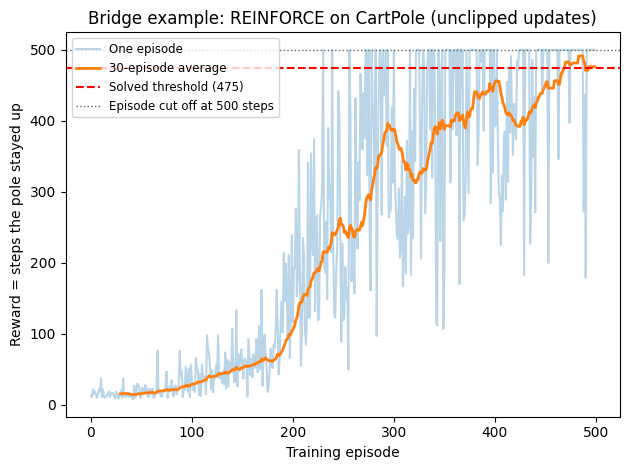


Biggest probability change in one update: median x1.03, largest x1.26 over 500 updates.
Updates that moved some action's probability by more than PPO's 20% clip: 4 of 500.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Fix the random seeds (PyTorch draws the actions, so its seed decides the run) so the numbers
# quoted in the text above and the figures below all describe the same run.
torch.manual_seed(42); np.random.seed(42)
# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')
# Seed the environment too, so the sequence of start states is the same on every run.
env.reset(seed=42); env.action_space.seed(42)

# Class `PolicyNet` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class PolicyNet(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(4, 128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy  = PolicyNet()
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy.parameters(), lr=2e-3)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; ep_rewards = []
# We also MEASURE how far each unclipped update moves the policy, because that distance is
# exactly the quantity PPO's clipping is designed to limit. One number per episode.
update_factors = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(500):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    # Two extra lists, used only for the measurement — they do not change the learning at all.
    visited_states=[]; taken_actions=[]
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(500):
        # Save a value in a name so the next lines can read it.
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        # Another assignment—same idea: store a value for the lines below.
        dist   = torch.distributions.Categorical(probs)
        # Another assignment—same idea: store a value for the lines below.
        action = dist.sample()
        # Add one new item to the end of a list (the list grows in place).
        log_probs.append(dist.log_prob(action))
        # Remember the state and the action so we can re-ask the policy about them after the update.
        visited_states.append(obs); taken_actions.append(int(action))
        # Save a value in a name so the next lines can read it.
        obs, r, done, trunc, _ = env.step(action.item())
        # Add one new item to the end of a list (the list grows in place).
        rewards_ep.append(r)
        # If the condition is True, run the indented block under this line.
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    G = 0; returns = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in reversed(rewards_ep):
        # Save a value in a name so the next lines can read it.
        G = r + GAMMA*G; returns.insert(0, G)
    # Another assignment—same idea: store a value for the lines below.
    returns = torch.tensor(returns).float()
    # Another assignment—same idea: store a value for the lines below.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()

    # ── Measure the size of the update (this is the PPO question) ───────────
    # Probability the CURRENT policy gives to each action it actually took...
    S_ep = torch.tensor(np.array(visited_states)).float(); A_ep = torch.tensor(taken_actions).long()
    with torch.no_grad():
        p_before = policy(S_ep).gather(1, A_ep.unsqueeze(1)).squeeze(1)
    # Execute: opt.zero_grad(); loss.backward(); opt.step()
    opt.zero_grad(); loss.backward(); opt.step()
    # ...and the probability the UPDATED policy gives to the same actions in the same states.
    with torch.no_grad():
        p_after = policy(S_ep).gather(1, A_ep.unsqueeze(1)).squeeze(1)
    # PPO calls p_after / p_before the "probability ratio". Store the biggest move in this update,
    # as a factor >= 1, so "1.30" reads as "one action's probability changed by 30% in one step".
    ratio = (p_after / p_before).numpy()
    update_factors.append(float(np.maximum(ratio, 1.0 / ratio).max()))

    # Add one new item to the end of a list (the list grows in place).
    ep_rewards.append(sum(rewards_ep))
    # If the condition is True, run the indented block under this line.
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

# Execute: env.close()
env.close()
# Save a value in a name so the next lines can read it.
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
# Thin line: every single episode. The scatter is the instability this lesson is about.
plt.plot(ep_rewards, alpha=0.3, label="One episode")
# Thick line: the 30-episode average, placed at the last episode of each window.
plt.plot(np.arange(len(ma)) + 29, ma, lw=2, label="30-episode average")
# The score Gymnasium calls "solved" for CartPole-v1.
plt.axhline(475, color='red', linestyle='--', label="Solved threshold (475)")
# CartPole-v1 stops every episode at 500 steps, so the flat top is a ceiling, not a plateau.
plt.axhline(500, color='0.4', linestyle=':', lw=1, label="Episode cut off at 500 steps")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Bridge example: REINFORCE on CartPole (unclipped updates)")
plt.xlabel("Training episode")
# On CartPole the reward IS the number of steps survived — say so on the axis.
plt.ylabel("Reward = steps the pole stayed up")
# Legend goes top-left, the one corner of this plot with no data in it.
plt.legend(loc="upper left", fontsize=8.5); plt.tight_layout(); plt.show()

# Print the measurement the next figure will use.
print(f"\nBiggest probability change in one update: median x{np.median(update_factors):.2f}, "
      f"largest x{np.max(update_factors):.2f} over {len(update_factors)} updates.")
print(f"Updates that moved some action's probability by more than PPO's 20% clip: "
      f"{sum(f > 1.2 for f in update_factors)} of {len(update_factors)}.")


### 👁️ Read the figure

**What it shows.** The bridge run: 500 episodes of REINFORCE on CartPole, one faint blue point per episode,
the thick orange line its 30-episode average. **No clipping anywhere** — every update is whatever size the
returns imply. Under the plot are two measured numbers you will need for the next figure: how far the biggest
single update moved an action's probability, and how many updates went past PPO's 20% limit.

**What to see.** The average climbs to the solved line, so the plain method does work here. But follow the
orange line closely: it reaches about 395 steps by episode 295 and is back down at about 315 by episode 320,
then reaches about 455 by episode 400 and falls to about 390 by episode 425. Those are stretches where the
agent unlearned what it had — the same regression the printed milestones show as 386.1 at episode 300 against
365.6 at episode 350. Meanwhile the printed measurement says the updates themselves were small: a typical one
changed an action's probability by about 3%.

**What it proves.** Small steps and stable learning are not the same thing. On a 500-step pole an update that
goes wrong costs you fifty episodes, and the curve recovers. The InstructGPT section above is about the case
where it does not: one over-large update on a model that took months to pretrain is not a recoverable dip.
That is the risk PPO's clipping is built to remove — which the next figure shows in the objective itself.

## CartPole step-through (GIF + slider)

Connects the **environment API** to **pixels** while you read the PPO training loop. Policy is **random** in this cell so it always runs; optional extension: plug in actions from your trained policy.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.

26 frames | return=25.0 | term=True | trunc=False


objc[72380]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a5fc138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11aaf89c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[72380]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a5fc188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11aaf8a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[72380]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a5fbc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11aaf8a68). T

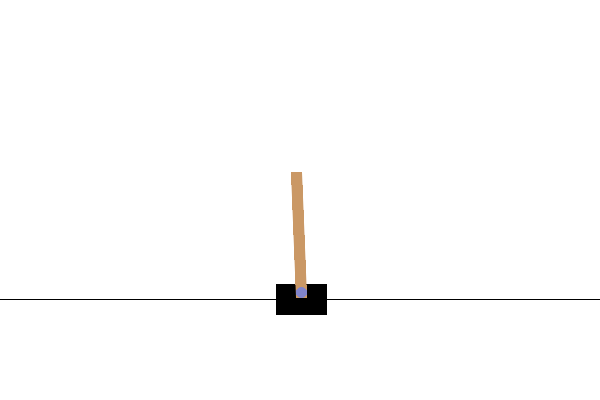

In [3]:
# Motion recap (optional visual): replay one CartPole episode as a GIF + step slider via the shared Course 09 helper.
# Why: watching the cart and pole move frame-by-frame connects the training numbers above to real behaviour.

%pip install ipywidgets pillow -q

import pathlib
import sys

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError("Could not find course09_step_viz.py — run from inside Course 09.")

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz

# Create the environment in rgb_array mode so every step can be captured as an image frame.
env_vis = gym.make("CartPole-v1", render_mode="rgb_array")


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def random_policy(obs, step):
    return int(env_vis.action_space.sample())


# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, random_policy, max_steps=100, seed=0
)
env_vis.close()

print(f"{len(frames)} frames | return={total_r:.1f} | term={term} | trunc={trunc}")
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="CartPole-v1 timestep")

In [4]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Schulman, J., Levine, S., Moritz, P. et al. (2015). *Trust Region Policy Optimization* (TRPO). ICML. <https://arxiv.org/abs/1502.05477>
2. Schulman, J., Wolski, F., Dhariwal, P., Radford, A. & Klimov, O. (2017). *Proximal Policy Optimization Algorithms* (PPO). arXiv:1707.06347. <https://arxiv.org/abs/1707.06347>
3. Andrychowicz, M., Raichuk, A., Stańczyk, P. et al. (2020). *What Matters in On-Policy Reinforcement Learning? A Large-Scale Empirical Study*. arXiv:2006.05990. <https://arxiv.org/abs/2006.05990>
4. Ouyang, L., Wu, J., Jiang, X. et al. (2022). *Training Language Models to Follow Instructions with Human Feedback* (InstructGPT — RLHF fine-tuning with PPO). NeurIPS. <https://arxiv.org/abs/2203.02155>
"""))

## 📚 References

1. Schulman, J., Levine, S., Moritz, P. et al. (2015). *Trust Region Policy Optimization* (TRPO). ICML. <https://arxiv.org/abs/1502.05477>
2. Schulman, J., Wolski, F., Dhariwal, P., Radford, A. & Klimov, O. (2017). *Proximal Policy Optimization Algorithms* (PPO). arXiv:1707.06347. <https://arxiv.org/abs/1707.06347>
3. Andrychowicz, M., Raichuk, A., Stańczyk, P. et al. (2020). *What Matters in On-Policy Reinforcement Learning? A Large-Scale Empirical Study*. arXiv:2006.05990. <https://arxiv.org/abs/2006.05990>
4. Ouyang, L., Wu, J., Jiang, X. et al. (2022). *Training Language Models to Follow Instructions with Human Feedback* (InstructGPT — RLHF fine-tuning with PPO). NeurIPS. <https://arxiv.org/abs/2203.02155>


## 💬 Discuss

The REINFORCE bridge run: **18.0 → 19.5 → 31.1 → 44.8 → 164.7 → 127.4 → 290.8 → 376.9 → 416.8 →
462.1**. Notice episode 250 (127.4) is *worse* than episode 200 (164.7). Argue these out.

1. PPO's fix is to clip the ratio between new and old action probabilities — typically at 1 ± 0.2.
   That number is a hyperparameter nobody derived. What behaviour would you expect from a clip of
   0.01, and from a clip of 2.0? Which of the two failures would be harder to detect from a training
   curve alone?
2. In RLHF the reward is a *model fitted to human rankings*, not a measured quantity. Name two ways
   that reward model could be wrong, and say what the optimiser would do with each. (You met the
   general version of this failure in Unit 1, lesson 06.)
3. GRPO drops the critic and compares several sampled answers to the same prompt instead. That works
   when you can check an answer automatically. Pick a task from your own field: is its reward
   verifiable in that sense? If not, what would you have to change about the task definition to make
   it so — and would the task still be worth doing?


## 📝 Summary

You learned **Policy Gradient** methods that directly optimize the policy without a value table. **Actor-Critic** combines a policy (actor) with a value estimator (critic) for lower variance. **PPO** is today's most-used algorithm — it powers OpenAI's ChatGPT RLHF training and robotics at Boston Dynamics.

### Step Guide

**What this cell does:** Draws PPO's clipped objective — the one formula that separates PPO from the bridge run above — and marks on it how far this notebook's own updates actually moved.

**How to read it (weak Python OK):** Nothing is trained here. The cell evaluates two formulas over a range of "probability ratios" and plots them; the only measured input is `update_factors`, collected during the run above.

**What to expect in the output:** One figure with two panels, one for an action that turned out better than expected and one for an action that turned out worse.

**If you feel lost:** Look only for the flat parts of the orange line. Flat means the objective stops rewarding a bigger change — that is the whole idea of clipping.

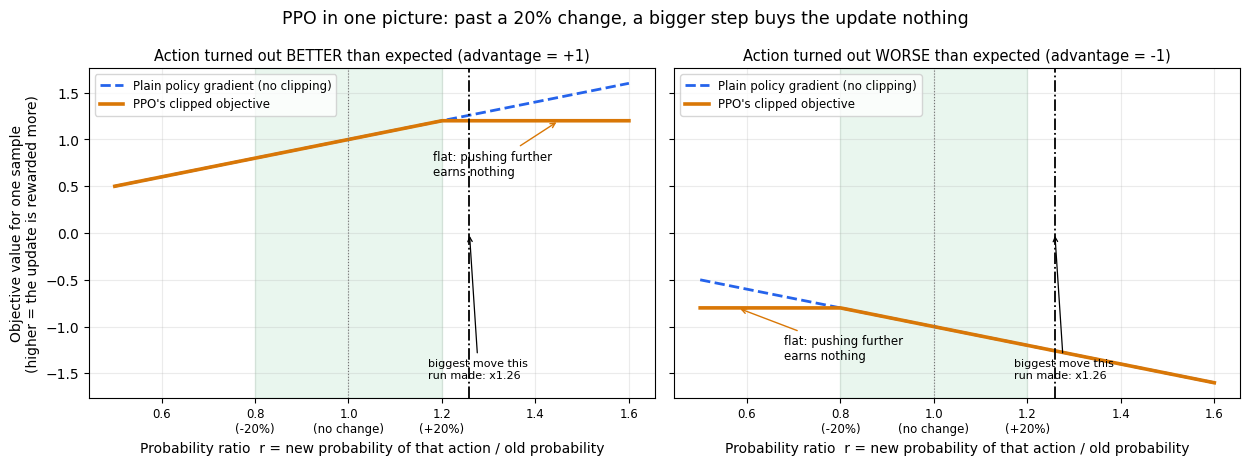

In [5]:
# Closing figure: PPO's clipped objective, drawn exactly as the formula defines it.
# Nothing is trained here and nothing is simulated — the two curves ARE the two loss functions,
# evaluated over a range of probability ratios. The one measured number comes from the run above.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# The probability ratio r = pi_new(a|s) / pi_old(a|s): how much MORE likely the updated policy is
# to take the action the old policy took. r = 1 means "the update changed nothing here".
ratio = np.linspace(0.5, 1.6, 400)
EPSILON = 0.2                       # PPO's usual clip width: the new policy may not profit past +/-20%

# The largest move this notebook's own unclipped run actually made (measured in the training cell).
biggest_move = float(np.max(update_factors))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.7), sharey=True)

# One panel for a good action (advantage above zero), one for a bad one (advantage below zero).
for ax, advantage, headline in zip(
        axes, [1.0, -1.0],
        ["Action turned out BETTER than expected (advantage = +1)",
         "Action turned out WORSE than expected (advantage = -1)"]):

    # Plain policy gradient: the objective keeps growing as long as you push the probability further.
    unclipped = ratio * advantage
    # PPO: take the pessimistic one of "unclipped" and "ratio pinned inside 1 +/- epsilon".
    clipped = np.minimum(unclipped, np.clip(ratio, 1 - EPSILON, 1 + EPSILON) * advantage)

    # Shade the band PPO is willing to reward, so the flat parts have an obvious cause.
    ax.axvspan(1 - EPSILON, 1 + EPSILON, color="#16a34a", alpha=0.09)
    ax.plot(ratio, unclipped, lw=2.0, color="#2563eb", ls="--",
            label="Plain policy gradient (no clipping)")
    ax.plot(ratio, clipped, lw=2.6, color="#d97706",
            label="PPO's clipped objective")
    # Mark the three ratios that matter, in the tick labels themselves.
    ax.set_xticks([0.6, 1 - EPSILON, 1.0, 1 + EPSILON, 1.4, 1.6])
    ax.set_xticklabels(["0.6", "0.8\n(-20%)", "1.0\n(no change)", "1.2\n(+20%)", "1.4", "1.6"], fontsize=8.5)
    ax.axvline(1.0, color="0.45", lw=0.8, ls=":")
    # Where this notebook's own biggest unclipped update landed.
    ax.axvline(biggest_move, color="black", lw=1.3, ls="-.")
    ax.annotate(f"biggest move this\nrun made: x{biggest_move:.2f}", xy=(biggest_move, 0.0),
                xytext=(0.60, 0.06), textcoords="axes fraction", fontsize=8,
                arrowprops=dict(arrowstyle="->", color="black", lw=0.9))
    ax.set_xlabel("Probability ratio  r = new probability of that action / old probability")
    ax.set_title(headline, fontsize=10.5)
    ax.legend(fontsize=8.5, loc="upper left")
    ax.grid(alpha=0.25)

# Both panels share one y-axis, so the two shapes really are comparable.
axes[0].set_ylabel("Objective value for one sample\n(higher = the update is rewarded more)")

# Point at the flat stretch that IS the clipping, once per panel.
axes[0].annotate("flat: pushing further\nearns nothing", xy=(1.45, 1.2), xytext=(1.18, 0.62),
                 fontsize=8.5, arrowprops=dict(arrowstyle="->", color="#d97706"))
axes[1].annotate("flat: pushing further\nearns nothing", xy=(0.58, -0.8), xytext=(0.68, -1.35),
                 fontsize=8.5, arrowprops=dict(arrowstyle="->", color="#d97706"))

fig.suptitle("PPO in one picture: past a 20% change, a bigger step buys the update nothing", fontsize=12.5)
plt.tight_layout()
plt.show()

### 👁️ Read the figure

**What you are looking at.** Not an experiment — the two loss functions themselves, drawn over the quantity
PPO cares about: the probability ratio `r`, how much more (or less) likely the updated policy is to take the
action the old policy took. `r = 1` on the x-axis means the update changed nothing for that action. Blue dashed
is plain policy gradient, orange is PPO's clipped objective, and the green band is the ±20% window PPO is
willing to reward. Both panels share one y-axis, so their shapes are directly comparable.

**What to see.** Where the two objectives agree the orange line is drawn on top of the blue one, so blue is
only visible where clipping has changed something. The blue line never stops climbing: the further the update pushes a good action's probability,
the more objective it earns, so nothing in the maths says "far enough". The orange line goes flat the moment
`r` leaves the green band — and a flat objective has zero gradient, so the update stops being paid to go
further. The right-hand panel is the mirror image: for an action that turned out worse than expected, the flat
part is on the *left*, capping how hard a single update can suppress it. The dash-dotted line is this
notebook's own record: across 500 unclipped updates, the biggest change to any action's probability was the
factor printed there.

**What it proves.** Clipping is not a penalty added on top of the objective; it *is* the objective, shaped so
that oversized steps earn nothing. And read the dash-dotted line honestly: on CartPole the unclipped updates
were almost all inside the band anyway (the printed count says how many of the 500 were not), so the guard rail
rarely fired here. That is the real lesson of the InstructGPT story above — the rail is cheap when you do not
need it, and it is the difference between a recoverable dip and a destroyed model when you do. Remember that
this notebook never runs PPO on the environment: you have seen its objective, and you have measured what
unclipped updates do, which is not the same as having measured PPO.

## ⚠️ Where this breaks

**The assumption that has to hold:** the reward you are optimising is a faithful measure of what you
want, and small policy steps are enough to keep the agent inside the region where that reward stays
meaningful.

- **Optimising a learned reward model is optimising a proxy.** This is Unit 1 lesson 06's
  CoastRunners failure at industrial scale. The KL penalty in RLHF exists precisely because, given
  enough freedom, the policy finds inputs where the reward model is wrong and high. That is not a bug
  in PPO; PPO is doing its job.
- **Reward signals can be uninformative and still move your metrics.** Shao et al., "Spurious
  Rewards: Rethinking Training Signals in RLVR" (arXiv 2506.10947, 2025) ran GRPO with **randomly
  assigned** rewards and still improved MATH-500 performance for Qwen2.5-Math-7B by **21.4
  percentage points**, against 29.1 for real, ground-truth rewards. The gain was largely a
  training-dynamics artefact, and it did not reproduce on Llama3 or OLMo2. Read every RL ablation
  with that result in mind, including your own.
- **Implementation details carry much of the performance.** Engstrom et al. ("Implementation Matters
  in Deep Policy Gradients", ICLR 2020) showed that PPO's advantage over TRPO is largely attributable
  to code-level choices — advantage normalisation, learning-rate annealing, value-loss clipping —
  rather than to the clipped objective by itself. "We used PPO" does not describe your algorithm.
- **This notebook does not implement PPO.** It says so in its own front matter, and it is worth
  repeating here: what runs below is REINFORCE, as a bridge. Do not leave with the impression that
  you have measured PPO's clipping — you have measured what happens without it.
- **Cheaper alternative:** if your reward is genuinely verifiable and you can sample several answers
  per prompt, GRPO removes the value network and much of the tuning surface. And if you simply want a
  model to follow instructions, supervised fine-tuning on good demonstrations gets most of the way
  there for a fraction of the machinery — RLHF's own pipeline starts with exactly that step.


## Closing Takeaway

**Teaching takeaway:** PPO improves policy optimization by limiting overly large updates, making learning more stable in practice.

**If students remember one idea:** A good policy update should improve behavior without changing the policy so much that learning collapses.

**Quick check before moving on:**
- Can you explain why clipped updates help PPO remain stable?
- Can you describe how PPO builds on policy gradient and actor-critic ideas?

**Bridge to the next step:** After the core algorithms, students need to learn how to monitor training quality and diagnose weak runs.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
